In [1]:
# Importing libraries

from __future__ import print_function
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')

In [2]:
df1 = pd.read_csv('datas/First_Crop_recommendation.csv')
df2 = pd.read_csv('datas/Second_Crop_recommendation.csv')

In [3]:
print("Dataset 1: Premieres lignes")
print(df1.head())

print("\nDataset 2: Premieres lignes")
print(df2.head())

Dataset 1: Premieres lignes
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Dataset 2: Premieres lignes
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [4]:
print("Dataset 1: Dernieres lignes")
print(df1.tail())

print("\nDataset 2: Dernieres lignes")
print(df2.tail())

Dataset 1: Dernieres lignes
        N   P   K  temperature   humidity        ph    rainfall   label
2195  107  34  32    26.774637  66.413269  6.780064  177.774507  coffee
2196   99  15  27    27.417112  56.636362  6.086922  127.924610  coffee
2197  118  33  30    24.131797  67.225123  6.362608  173.322839  coffee
2198  117  32  34    26.272418  52.127394  6.758793  127.175293  coffee
2199  104  18  30    23.603016  60.396475  6.779833  140.937041  coffee

Dataset 2: Dernieres lignes
        N   P   K  temperature   humidity        ph    rainfall   label
1692  117  86  48    28.695620  82.541958  6.225225  116.161684  banana
1693  114  94  53    26.335449  76.853201  6.190757  118.685826  banana
1694  110  78  50    25.937302  78.898644  5.915569   98.217475  banana
1695   94  70  48    25.136865  84.883944  6.195152   91.464425  banana
1696   80  71  47    27.505277  80.797840  6.156373  105.077699  banana


In [5]:
print("Dataset 1: Taille = ", df1.size)
print("Dataset 2: Taille = ", df2.size)

Dataset 1: Taille =  17600
Dataset 2: Taille =  13576


In [6]:
print("Dataset 1: Formes = ", df1.shape)
print("Dataset 2: Formes = ", df2.shape)

Dataset 1: Formes =  (2200, 8)
Dataset 2: Formes =  (1697, 8)


In [7]:
print("Dataset 1: Colonnes: \n", df1.columns)
print("\nDataset 2: Colonnes: \n", df2.columns)

Dataset 1: Colonnes: 
 Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

Dataset 2: Colonnes: 
 Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


In [8]:
print("Dataset 1: Labels = ", df1['label'].unique())
print("\nDataset 2: Labels = ", df2['label'].unique())

Dataset 1: Labels =  ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']

Dataset 2: Labels =  ['rice' 'maize' 'Soyabeans' 'beans' 'peas' 'groundnuts' 'cowpeas' 'banana'
 'mango' 'grapes' 'watermelon' 'apple' 'orange' 'cotton' 'coffee']


In [9]:
print("Dataset 1: Types: \n", df1.dtypes)
print("\nDataset 2: Types: \n", df2.dtypes)

Dataset 1: Types: 
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Dataset 2: Types: 
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


In [10]:
# Checking Missing Values
print("Dataset 1: Missing Values:")
print(df1.isnull().sum())

print("\nDataset 2: Missing Values:")
print(df2.isnull().sum())

Dataset 1: Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Dataset 2: Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [11]:
# Merging Datasets 

df = pd.concat([df1, df2])

df = df.drop_duplicates()

In [12]:
df.size

25048

In [13]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
1589,22,67,78,17.366064,14.724575,6.204091,73.326675,Soyabeans
1590,36,65,80,18.487201,16.979216,6.051091,75.874456,Soyabeans
1591,59,60,84,19.230253,18.967256,7.690962,95.709920,Soyabeans
1592,54,77,85,17.341861,17.366243,7.829211,84.746067,Soyabeans


In [14]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee',
       'Soyabeans', 'beans', 'peas', 'groundnuts', 'cowpeas'],
      dtype=object)

In [15]:
df['label'].value_counts()

label
rice           176
maize          149
banana         145
coffee         144
apple          134
watermelon     134
orange         131
mango          130
Soyabeans      130
cotton         130
grapes         128
coconut        100
groundnuts     100
peas           100
beans          100
chickpea       100
jute           100
mungbean       100
papaya         100
blackgram      100
kidneybeans    100
muskmelon      100
pigeonpeas     100
mothbeans      100
pomegranate    100
lentil         100
cowpeas        100
Name: count, dtype: int64

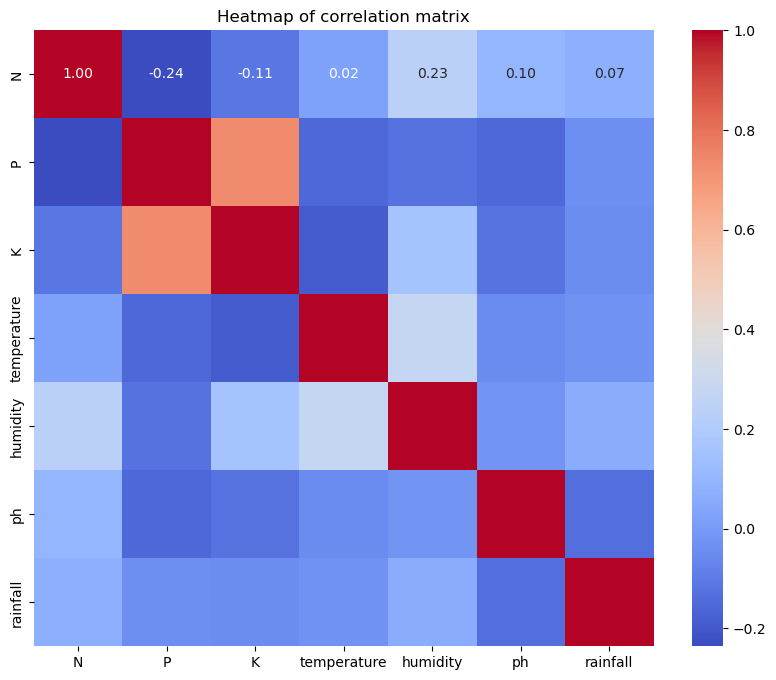

In [16]:
# sns.heatmap(df.corr(), annot=True)
df_numeric = df.select_dtypes(include=[float, int])

# Correlation matrix
corr_matrix = df_numeric.corr()

# Print the heatmap of matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of correlation matrix')
plt.show()


### Seperating features and target label

In [17]:
features = df.drop('label', axis=1)
labels = df['label']
features

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
1589,22,67,78,17.366064,14.724575,6.204091,73.326675
1590,36,65,80,18.487201,16.979216,6.051091,75.874456
1591,59,60,84,19.230253,18.967256,7.690962,95.709920
1592,54,77,85,17.341861,17.366243,7.829211,84.746067


In [18]:
# Initialzing empty lists to append all model's name and corresponding name
acc = []
model = []

In [19]:
# Splitting into train and test data

from sklearn.model_selection import train_test_split

Xtrain, Xtest, Ytrain, Ytest = train_test_split(features, labels, test_size = 0.2, random_state = 2)
# Xtrain, Xtest, Ytrain, Ytest = train_test_split(features,target,test_size = 0.2,random_state =2)

# Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier

DecisionTree = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=5)

DecisionTree.fit(Xtrain,Ytrain)

predicted_values = DecisionTree.predict(Xtest)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Decision Tree')
print("DecisionTrees's Accuracy is: ", x*100)

print(classification_report(Ytest,predicted_values))

DecisionTrees's Accuracy is:  74.64114832535886
              precision    recall  f1-score   support

   Soyabeans       0.49      1.00      0.66        20
       apple       1.00      1.00      1.00        27
      banana       0.94      1.00      0.97        17
       beans       0.45      0.88      0.60        17
   blackgram       0.00      0.00      0.00        17
    chickpea       0.00      0.00      0.00        21
     coconut       0.96      1.00      0.98        23
      coffee       1.00      1.00      1.00        24
      cotton       1.00      1.00      1.00        25
     cowpeas       0.00      0.00      0.00        25
      grapes       1.00      1.00      1.00        27
  groundnuts       0.44      1.00      0.61        24
        jute       1.00      0.17      0.29        24
 kidneybeans       0.00      0.00      0.00        18
      lentil       0.48      0.86      0.62        14
       maize       1.00      1.00      1.00        35
       mango       1.00      1.00

In [21]:
from sklearn.model_selection import cross_val_score

In [22]:
# Cross validation score (Decision Tree)
score = cross_val_score(DecisionTree, features, labels,cv=5)

In [23]:
score

array([0.7814992 , 0.77795527, 0.77955272, 0.76837061, 0.73961661])

### Saving trained Decision Tree model

In [25]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
DT_pkl_filename = '../api/models/DecisionTree.pkl'
# Open the file to save as pkl file
DT_Model_pkl = open(DT_pkl_filename, 'wb')
pickle.dump(DecisionTree, DT_Model_pkl)
# Close the pickle instances
DT_Model_pkl.close()

# Guassian Naive Bayes

In [26]:
from sklearn.naive_bayes import GaussianNB

NaiveBayes = GaussianNB()

NaiveBayes.fit(Xtrain,Ytrain)

predicted_values = NaiveBayes.predict(Xtest)
x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Naive Bayes')
print("Naive Bayes's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

Naive Bayes's Accuracy is:  0.7751196172248804
              precision    recall  f1-score   support

   Soyabeans       0.49      0.95      0.64        20
       apple       1.00      1.00      1.00        27
      banana       1.00      1.00      1.00        17
       beans       0.22      0.24      0.23        17
   blackgram       1.00      1.00      1.00        17
    chickpea       0.50      0.05      0.09        21
     coconut       1.00      1.00      1.00        23
      coffee       0.96      1.00      0.98        24
      cotton       0.96      1.00      0.98        25
     cowpeas       0.39      0.28      0.33        25
      grapes       1.00      1.00      1.00        27
  groundnuts       0.29      0.25      0.27        24
        jute       0.90      0.79      0.84        24
 kidneybeans       0.24      0.22      0.23        18
      lentil       1.00      1.00      1.00        14
       maize       1.00      0.97      0.99        35
       mango       1.00      1.00 

In [27]:
# Cross validation score (NaiveBayes)
score = cross_val_score(NaiveBayes,features,labels,cv=5)
score

array([0.83253589, 0.82428115, 0.82587859, 0.81789137, 0.83067093])

### Saving trained Guassian Naive Bayes model

In [29]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
NB_pkl_filename = '../api/models/NBClassifier.pkl'
# Open the file to save as pkl file
NB_Model_pkl = open(NB_pkl_filename, 'wb')
pickle.dump(NaiveBayes, NB_Model_pkl)
# Close the pickle instances
NB_Model_pkl.close()

# Support Vector Machine (SVM)

In [30]:
from sklearn.svm import SVC

SVM = SVC(gamma='auto')

SVM.fit(Xtrain,Ytrain)

predicted_values = SVM.predict(Xtest)

x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('SVM')
print("SVM's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

SVM's Accuracy is:  0.2679425837320574
              precision    recall  f1-score   support

   Soyabeans       0.30      0.40      0.34        20
       apple       1.00      0.52      0.68        27
      banana       1.00      0.47      0.64        17
       beans       0.00      0.00      0.00        17
   blackgram       0.00      0.00      0.00        17
    chickpea       0.00      0.00      0.00        21
     coconut       1.00      0.04      0.08        23
      coffee       1.00      0.42      0.59        24
      cotton       1.00      0.48      0.65        25
     cowpeas       0.00      0.00      0.00        25
      grapes       1.00      0.33      0.50        27
  groundnuts       0.00      0.00      0.00        24
        jute       1.00      0.04      0.08        24
 kidneybeans       0.00      0.00      0.00        18
      lentil       0.00      0.00      0.00        14
       maize       1.00      0.66      0.79        35
       mango       1.00      0.41      0.5

In [31]:
# Cross validation score (SVM)
score = cross_val_score(SVM,features,labels,cv=5)
score

array([0.27591707, 0.17571885, 0.2028754 , 0.29073482, 0.49361022])

# Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

LogReg = LogisticRegression(random_state=2)

LogReg.fit(Xtrain,Ytrain)

predicted_values = LogReg.predict(Xtest)

x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('Logistic Regression')
print("Logistic Regression's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

Logistic Regression's Accuracy is:  0.7320574162679426
              precision    recall  f1-score   support

   Soyabeans       0.47      0.95      0.63        20
       apple       1.00      1.00      1.00        27
      banana       1.00      1.00      1.00        17
       beans       0.38      0.47      0.42        17
   blackgram       0.59      0.59      0.59        17
    chickpea       0.00      0.00      0.00        21
     coconut       1.00      1.00      1.00        23
      coffee       0.92      1.00      0.96        24
      cotton       0.88      0.84      0.86        25
     cowpeas       0.22      0.08      0.12        25
      grapes       1.00      1.00      1.00        27
  groundnuts       0.30      0.29      0.30        24
        jute       0.62      0.33      0.43        24
 kidneybeans       0.36      0.28      0.31        18
      lentil       0.93      0.93      0.93        14
       maize       0.84      0.91      0.88        35
       mango       0.97   

In [33]:
# Cross validation score (Logistic Regression)
score = cross_val_score(LogReg,features,labels,cv=5)
score

array([0.76714514, 0.77476038, 0.78594249, 0.77955272, 0.74760383])

### Saving trained Logistic Regression model

In [34]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
LR_pkl_filename = '../api/models/LogisticRegression.pkl'
# Open the file to save as pkl file
LR_Model_pkl = open(DT_pkl_filename, 'wb')
pickle.dump(LogReg, LR_Model_pkl)
# Close the pickle instances
LR_Model_pkl.close()

# Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=20, random_state=0)
RF.fit(Xtrain,Ytrain)

predicted_values = RF.predict(Xtest)

x = metrics.accuracy_score(Ytest, predicted_values)
acc.append(x)
model.append('RF')
print("RF's Accuracy is: ", x)

print(classification_report(Ytest,predicted_values))

RF's Accuracy is:  0.7097288676236044
              precision    recall  f1-score   support

   Soyabeans       0.19      0.25      0.22        20
       apple       1.00      1.00      1.00        27
      banana       1.00      1.00      1.00        17
       beans       0.06      0.06      0.06        17
   blackgram       1.00      1.00      1.00        17
    chickpea       0.00      0.00      0.00        21
     coconut       1.00      1.00      1.00        23
      coffee       1.00      1.00      1.00        24
      cotton       1.00      1.00      1.00        25
     cowpeas       0.06      0.04      0.05        25
      grapes       1.00      1.00      1.00        27
  groundnuts       0.20      0.21      0.20        24
        jute       0.96      0.92      0.94        24
 kidneybeans       0.06      0.06      0.06        18
      lentil       1.00      1.00      1.00        14
       maize       1.00      1.00      1.00        35
       mango       1.00      1.00      1.00

In [36]:
# Cross validation score (Random Forest)
score = cross_val_score(RF,features,labels,cv=5)
score

array([0.82296651, 0.81309904, 0.80830671, 0.80351438, 0.82428115])

### Saving trained Random Forest model

In [37]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
RF_pkl_filename = '../api/models/RandomForest.pkl'
# Open the file to save as pkl file
RF_Model_pkl = open(RF_pkl_filename, 'wb')
pickle.dump(RF, RF_Model_pkl)
# Close the pickle instances
RF_Model_pkl.close()

# XGBoost

In [38]:
!pip install xgboost

In [39]:
import xgboost as xgb

label_encoder = LabelEncoder()
target_encoded = label_encoder.fit_transform(labels)

xtrain, xtest, ytrain, ytest = train_test_split(features, target_encoded, test_size=0.2, random_state=42)

XB = xgb.XGBClassifier()
XB.fit(xtrain, ytrain)

predicted_values = XB.predict(xtest)

x = metrics.accuracy_score(ytest, predicted_values)
acc.append(x)
model.append('XGBoost')
print("XGBoost's Accuracy is: ", x)

print(classification_report(ytest,predicted_values))

XGBoost's Accuracy is:  0.6842105263157895
              precision    recall  f1-score   support

           0       0.19      0.19      0.19        27
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        34
           3       0.14      0.14      0.14        22
           4       1.00      1.00      1.00        16
           5       0.00      0.00      0.00        22
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        26
           8       0.96      1.00      0.98        25
           9       0.05      0.05      0.05        19
          10       1.00      1.00      1.00        33
          11       0.17      0.23      0.20        22
          12       0.94      1.00      0.97        17
          13       0.05      0.05      0.05        19
          14       1.00      0.95      0.97        19
          15       1.00      0.97      0.99        35
          16       1.00      1.00     

In [40]:
# Cross validation score (XGBoost)
score = cross_val_score(XB,features,target_encoded,cv=5)
score

array([0.82296651, 0.81469649, 0.80670927, 0.80511182, 0.81629393])

### Saving trained XGBoost model

In [41]:
import pickle
# Dump the trained Naive Bayes classifier with Pickle
XB_pkl_filename = '../api/models/XGBoost.pkl'
# Open the file to save as pkl file
XB_Model_pkl = open(XB_pkl_filename, 'wb')
pickle.dump(XB, XB_Model_pkl)
# Close the pickle instances
XB_Model_pkl.close()

## Accuracy Comparison

<Axes: title={'center': 'Accuracy Comparison'}, xlabel='Accuracy', ylabel='Algorithm'>

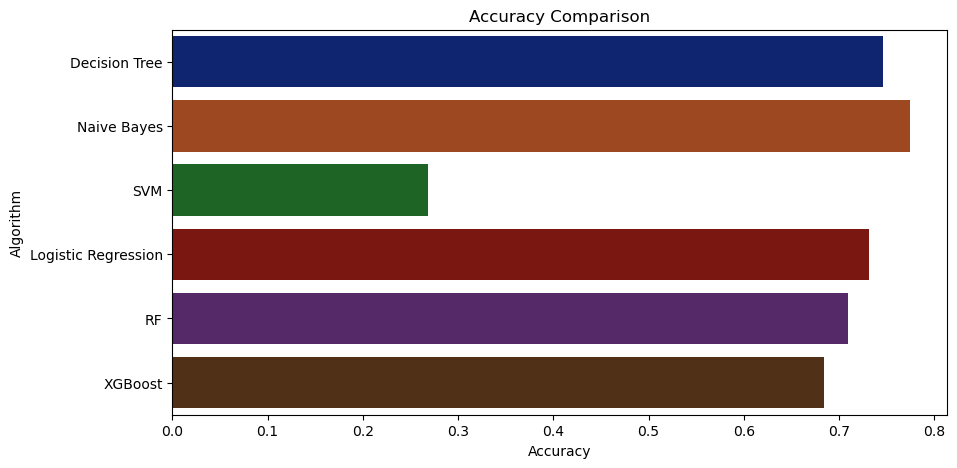

In [42]:
plt.figure(figsize=[10,5],dpi = 100)
plt.title('Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
sns.barplot(x = acc,y = model,palette='dark')

In [43]:
accuracy_models = dict(zip(model, acc))
for k, v in accuracy_models.items():
    print (k, '-->', v)

Decision Tree --> 0.7464114832535885
Naive Bayes --> 0.7751196172248804
SVM --> 0.2679425837320574
Logistic Regression --> 0.7320574162679426
RF --> 0.7097288676236044
XGBoost --> 0.6842105263157895


## Making a prediction

In [44]:
data = np.array([[104,18, 30, 23.603016, 60.3, 6.7, 140.91]])
# predictionRF = RF.predict(data)
# print("Random Forest: ", predictionRF)

predictionNB = NaiveBayes.predict(data)
print("Result with Naives Bayes: ", predictionNB)

Result with Naives Bayes:  ['coffee']


In [45]:
data = np.array([[83, 45, 60, 28, 70.3, 7.0, 150.9]])
# predictionRF = RF.predict(data)
# print("Random Forest: ", predictionRF)

predictionNB = NaiveBayes.predict(data)
print("Result with Naives Bayes: ", predictionNB)

Result with Naives Bayes:  ['jute']
